In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Caricamento del dataset
iris = load_iris()

In [ ]:

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})
columns = df.columns.tolist()[:-1]  # Escludiamo la colonna 'target'
#print(df['target'])

print(columns)
df.iloc[1,:]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


sepal_length    4.9
sepal_width     3.0
petal_length    1.4
petal_width     0.2
target          0.0
Name: 1, dtype: float64

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


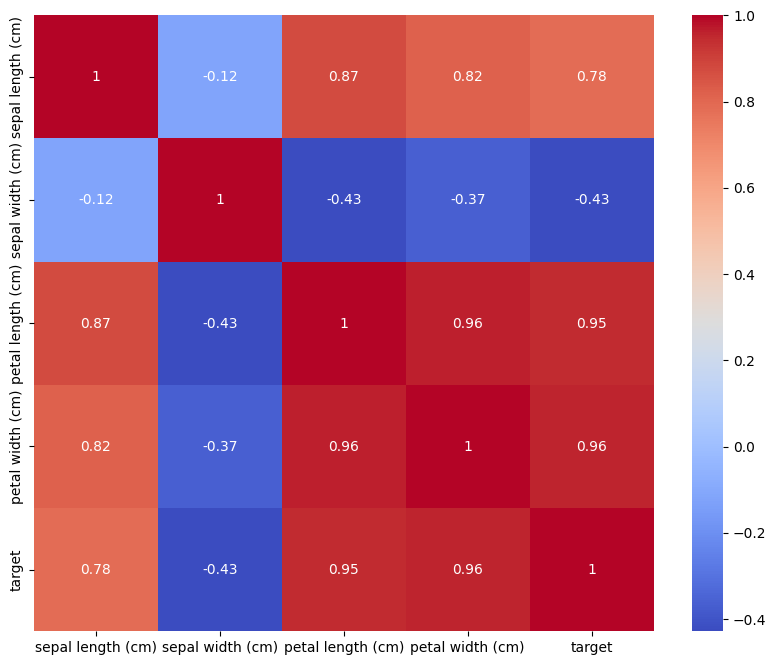

In [2]:
print(df.isnull().sum())
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [4]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1) Load data
X, y = load_iris(return_X_y=True)



# 2) Train/Test split (test set held out and used ONLY at the end)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # keep class proportions
    random_state=42
)

# 3) Pipeline: scaling + KNN (prevents data leakage in CV)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# 4) Hyperparameter grid to search (k, weighting, distance)
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

# 5) Cross-validation ONLY on the training set
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 6) Grid search (find best hyperparameters on train via CV)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,        # after CV, refit best model on ALL X_train
    return_train_score=True
)

gs.fit(X_train, y_train)

print("Best params (from CV on train):", gs.best_params_)
print("Best CV accuracy (mean over folds):", gs.best_score_)

# 7) Best model already refit on the entire training set
best_model = gs.best_estimator_

# 8) Final evaluation on the held-out test set (unbiased estimate)
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", test_acc)

test_pre = precision_score(y_test, y_pred, average="macro")
print("\nTest precision:", test_pre)

test_rec = recall_score(y_test, y_pred, average="macro")
print("\nTest recall:", test_rec)

test_f1  = f1_score(y_test, y_pred, average="macro")
print("\nTest f1:", test_f1)



#print("\nClassification report:\n", classification_report(y_test, y_pred))

Feature columns: ['feature_0', 'feature_1', 'feature_2', 'feature_3']


KeyboardInterrupt: 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="saga", max_iter=5000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", test_acc)

test_pre = precision_score(y_test, y_pred, average="macro")
print("\nTest precision:", test_pre)

test_rec = recall_score(y_test, y_pred, average="macro")
print("\nTest recall:", test_rec)

test_f1  = f1_score(y_test, y_pred, average="macro")
print("\nTest f1:", test_f1)

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/knn_model_pipe.joblib")
joblib.dump(pipe, "models/mlr_model_pipe.joblib")
joblib.dump(columns, "models/columns.joblib")

['models/columns.joblib']